In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv(r"C:\Users\Sreeja Banerjee\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


Missing values check

In [2]:
df.isna().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate values check

In [3]:
df.duplicated().sum()

np.int64(0)

Check for blank spaces

In [4]:
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [5]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [6]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Null values handle

In [7]:
df.dropna(inplace=True)

Check data types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

Target Variable Distribution(Churn)

In [10]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [11]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

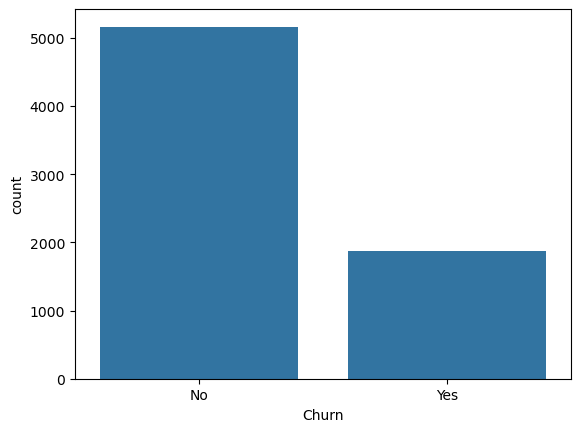

In [12]:
sns.countplot(data=df, x="Churn")
plt.show()

Numerical Feature Analysis (Histograms)

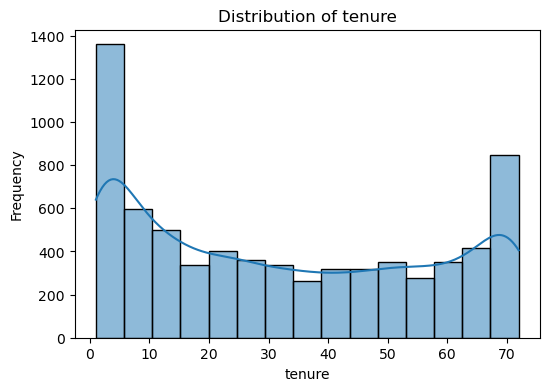

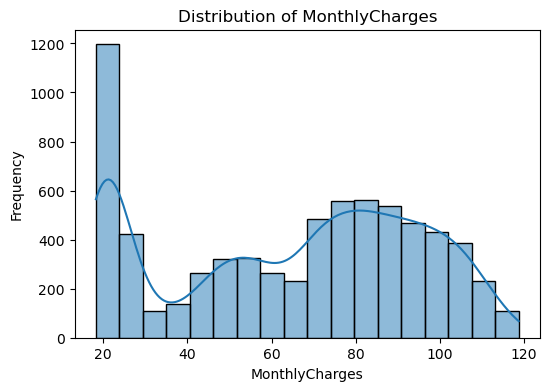

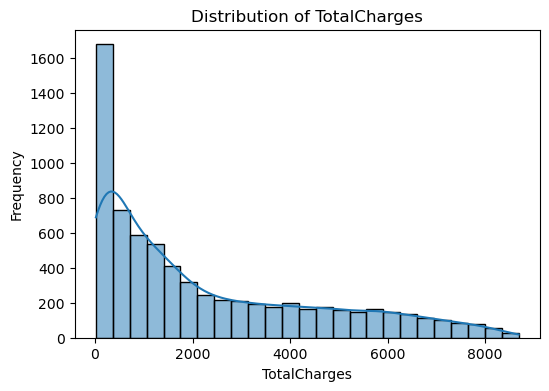

In [30]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('SeniorCitizen')

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Outlier detection (Boxplot)

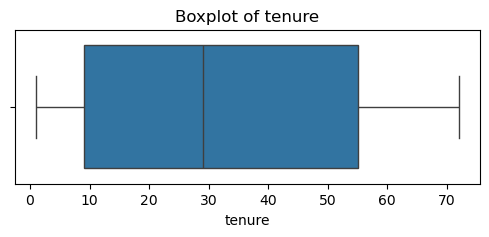

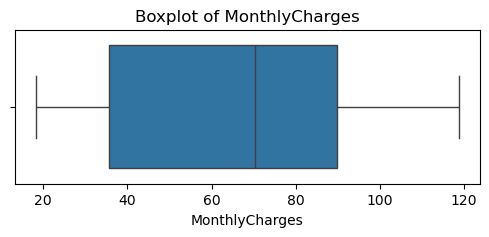

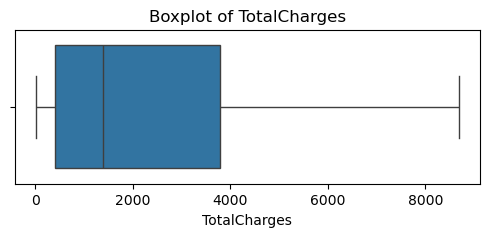

In [29]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('SeniorCitizen')

for col in numerical_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Numerical Features vs Churn

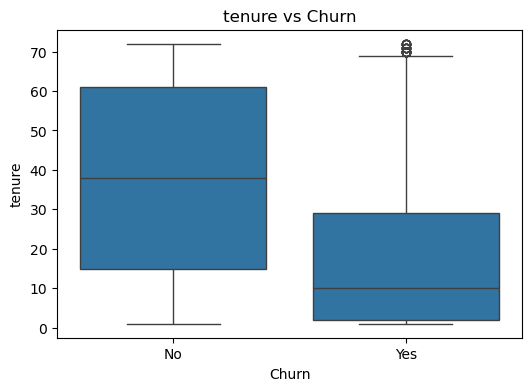

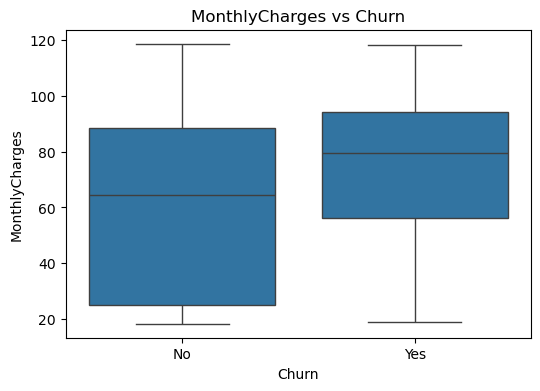

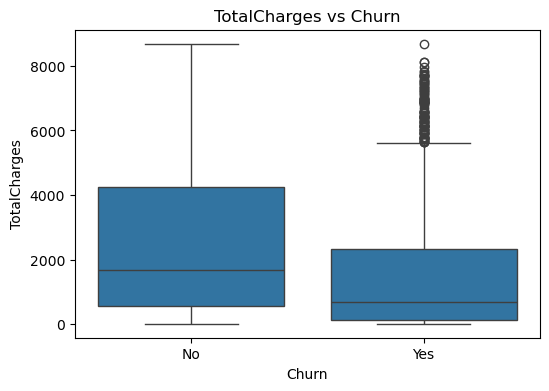

In [33]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("SeniorCitizen")

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} vs Churn")
    plt.show()

Business Insights (Numerical Features vs Churn):
1. Customers who churn (yes), have a significantly lower median tenure compared to retained customers.
2.  Customers who churn (yes), have a noticeably higher median monthly charge compared to the customers who stayed.
3.  Customers who churn (yes), have significantly lower median in total charge compared.It means the customers who didn't stay, spent far less than the customers who stayed. 

Summary Statistics

In [34]:
for col in numerical_cols:
    print(f"\n{'='*50}")
    print(f"Statistics for {col}")
    print(df[col].describe())


Statistics for tenure
count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Statistics for MonthlyCharges
count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

Statistics for TotalCharges
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64


Correlation Heatmap

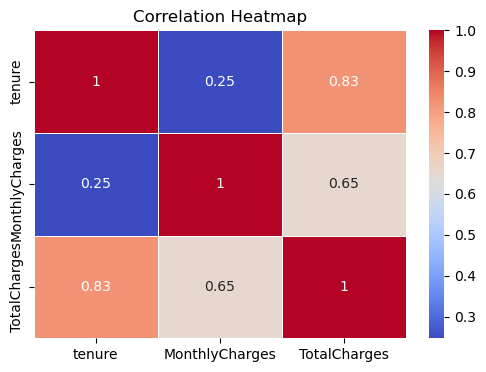

In [42]:
plt.figure(figsize=(6,4))
sns.heatmap(df[numerical_cols].corr(),
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

Insights:
There are two correlations have been seen without correlating the self-
1. Total charges highly correlated with tenure.
2. Monthly charges highly correlated with Total charges.

Categorical Feature Analysis

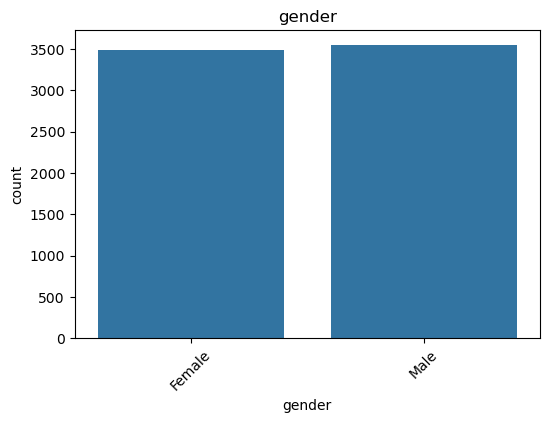

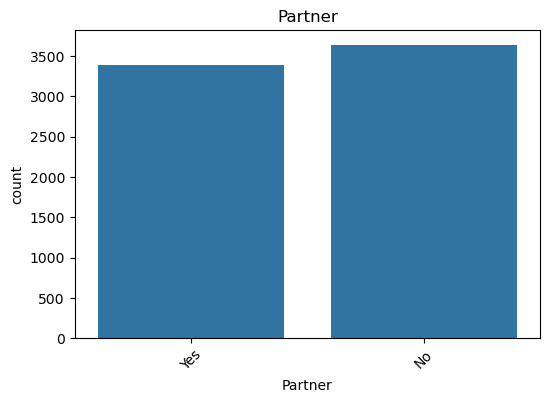

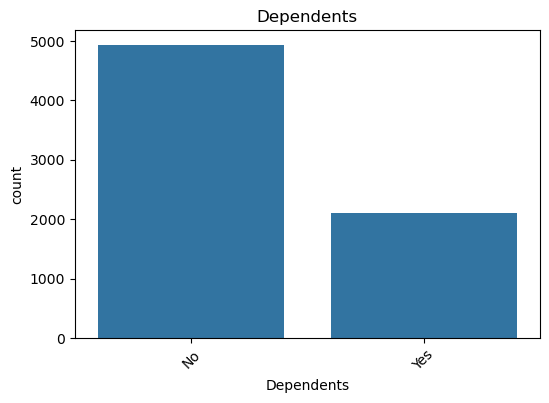

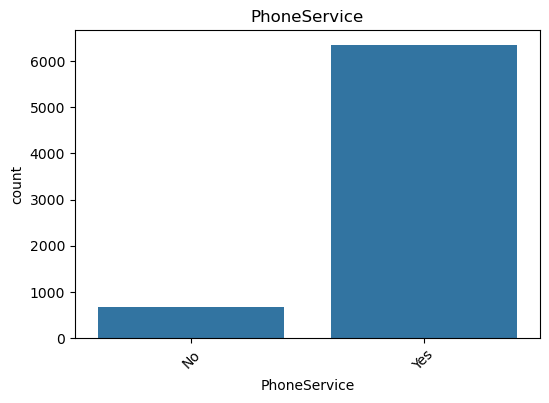

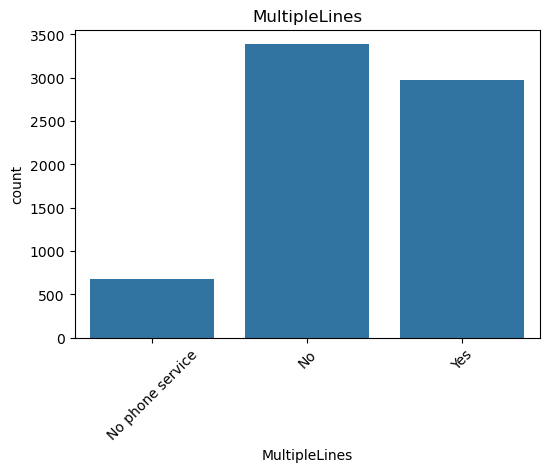

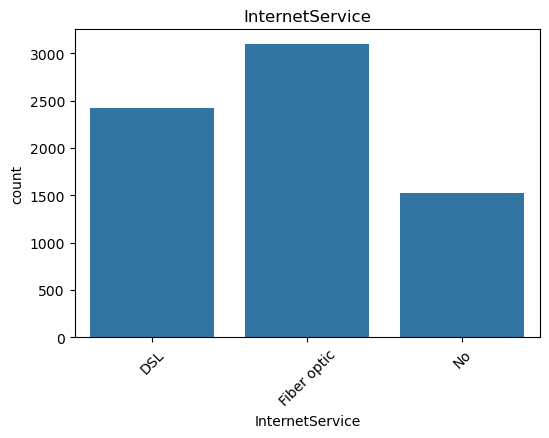

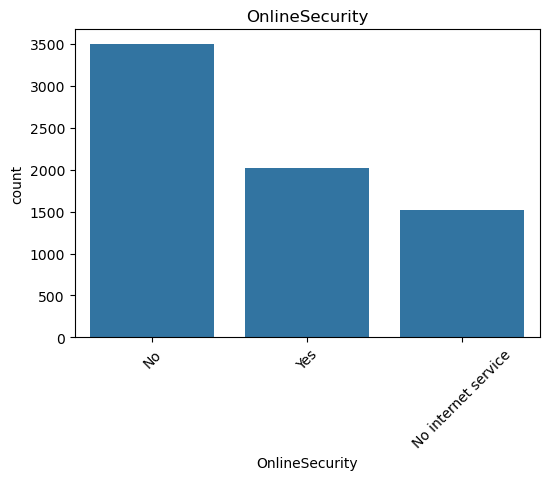

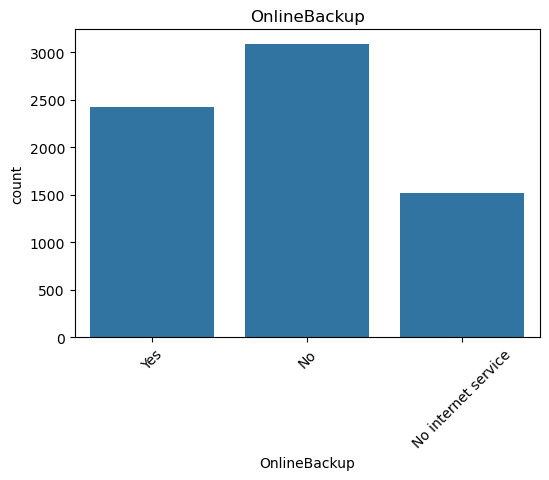

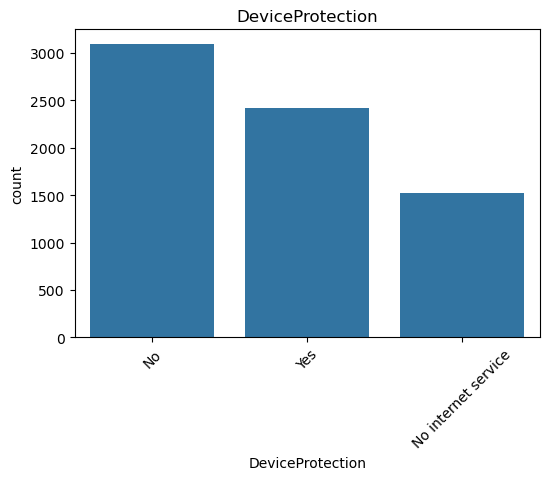

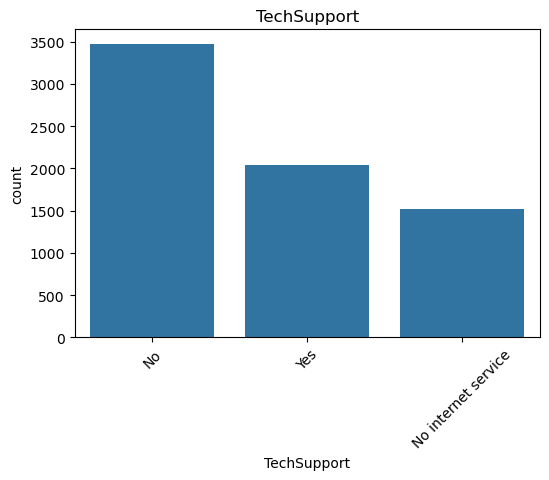

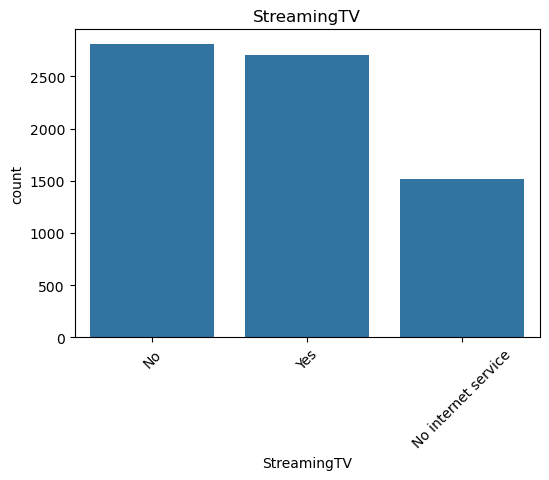

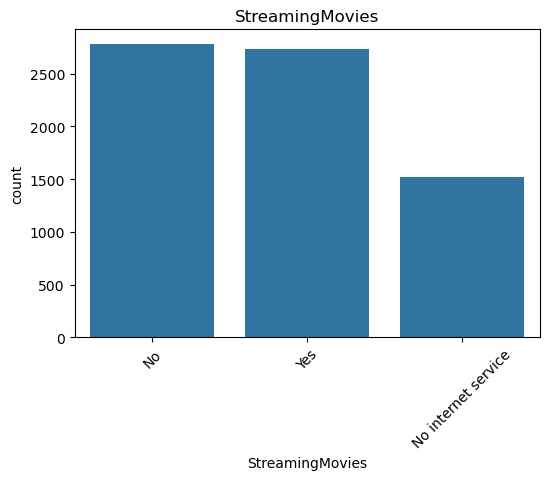

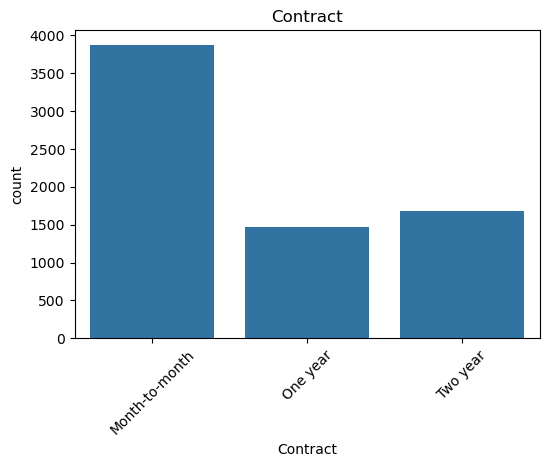

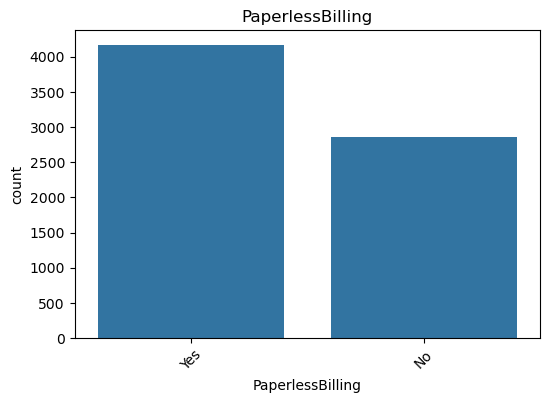

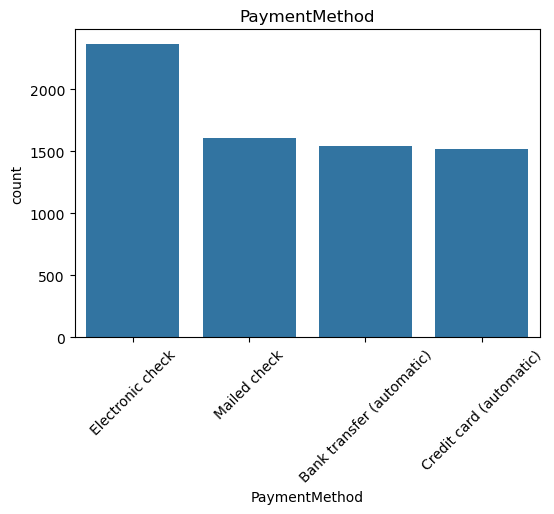

In [38]:
categorical_cols = df.select_dtypes(include='object').columns.drop(['Churn','customerID'])

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

Categorical Features vs Churn

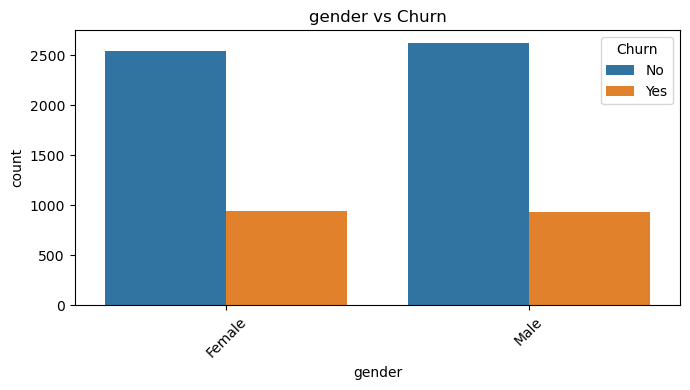

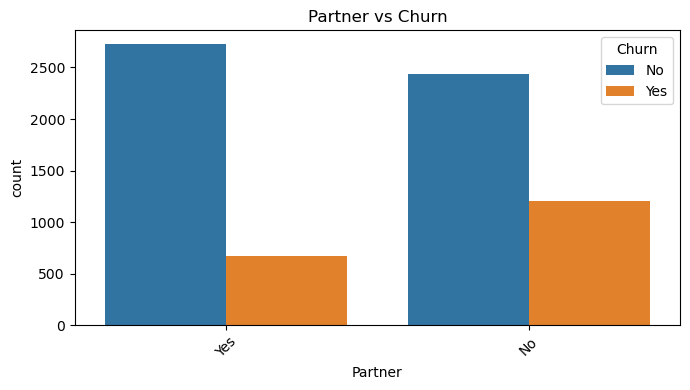

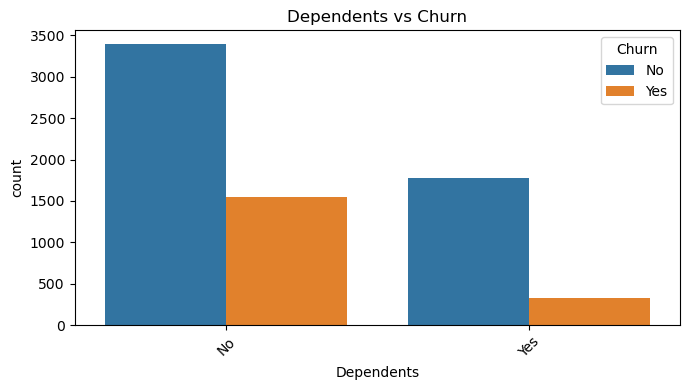

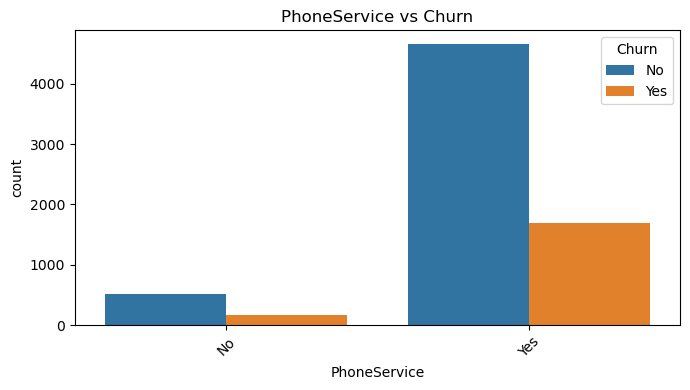

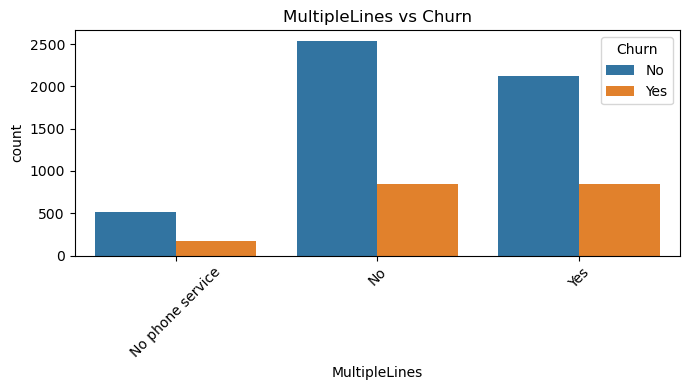

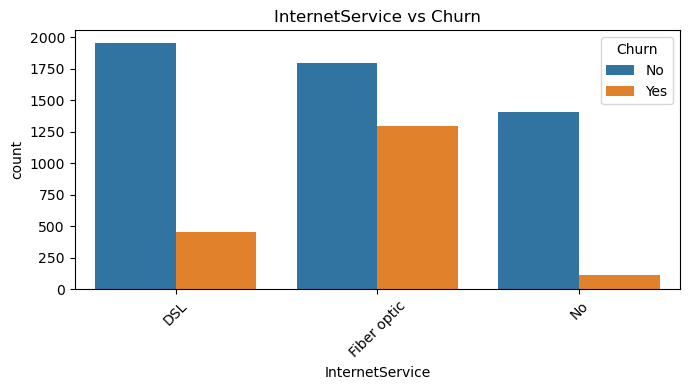

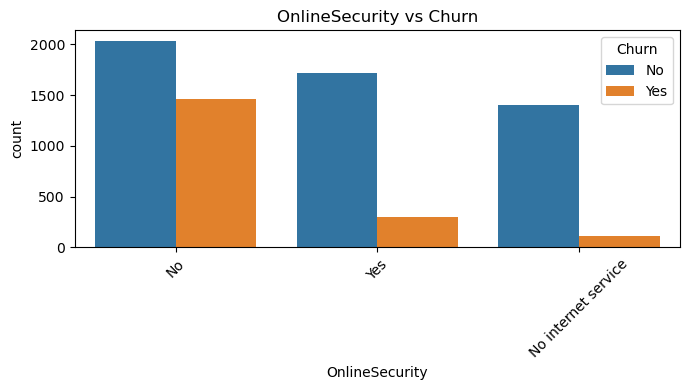

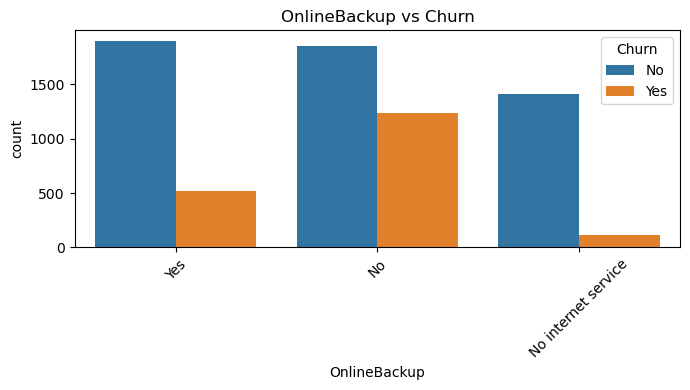

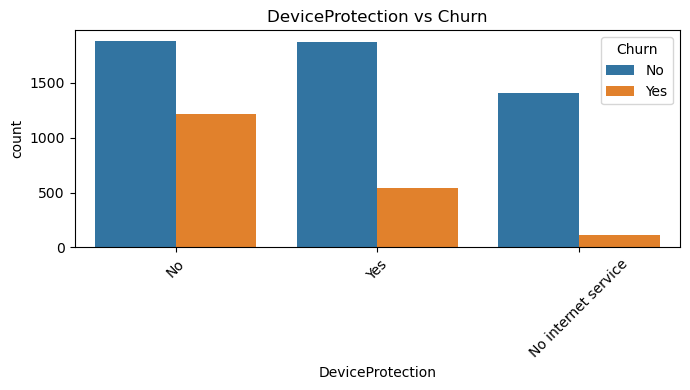

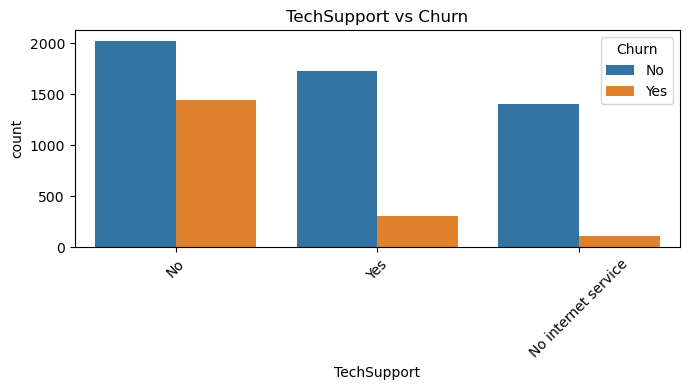

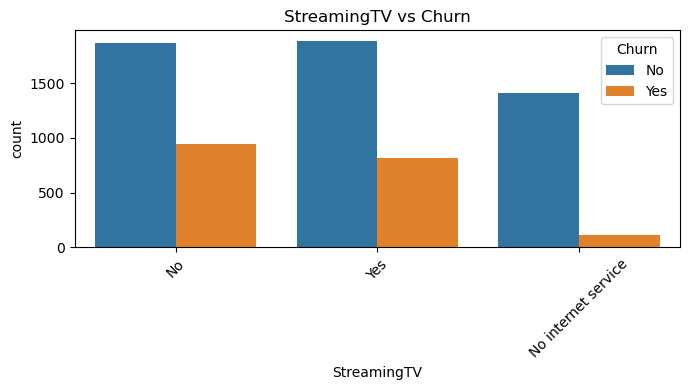

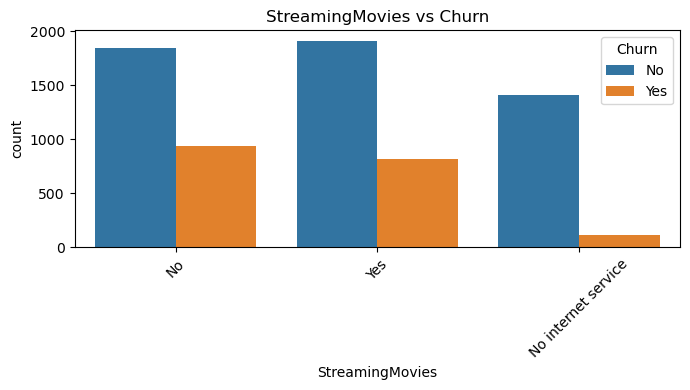

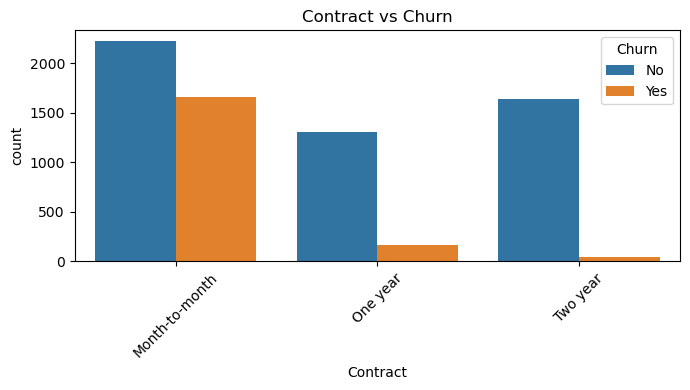

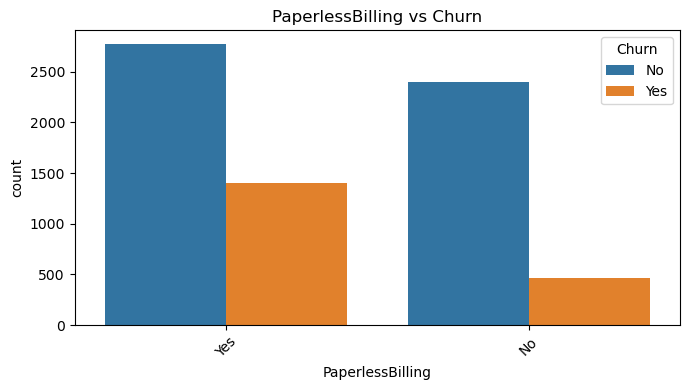

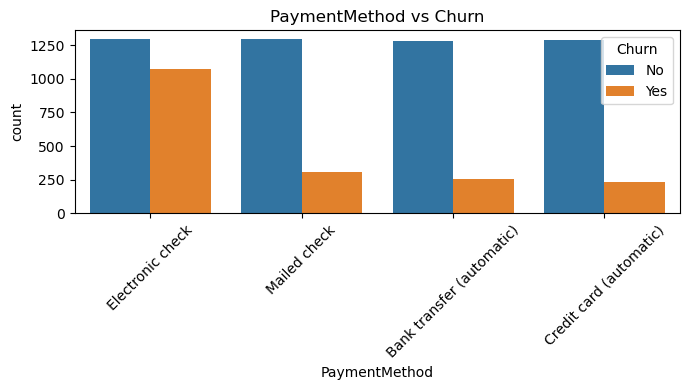

In [51]:
categorical_cols = df.select_dtypes(include='object').columns.drop(['Churn','customerID'])

for col in categorical_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Business Insights from 'Categorical features vs Churn':
1. Gender vs Churn: The churn rate is nearly the same for both male and female customers, indicating that gender does not have a significant impact on customer churn.
2. Partner vs Churn: Customers with partners have a lower churn rate than customers without partners. Having a partner may be associated with greater customer stability and retention.
3. Partner vs Churn: The customers who have partners have fewer churn rate tehn the customers who don't have any parnters.The partnership commitments improve teh customer retention.
4. Dependents vs Churn: Customers without dependents have a higher churn rate, indicating that family customers are generally more loyal.
5. Phone service vs Churn: Customers with phone service show a higher number of churn cases. However, since most customers subscribe to phone service, this pattern should be interpreted with caution and compared using churn percentages rather than raw counts.
6. Multiple lines vs Churn: The customers with no phone service have fewer churn count rather than the customers having multiples lines. Whether the customers having multiple lines or not, are eventually almost same churn rate.
7. InternetService vs Churn: Customers using Fiber Optic internet have a higher churn count than DSL users, suggesting possible issues related to pricing, expectations, or service quality.
8. OnlineSecurity vs Churn: Customers who do not subscribe to Online Security services exhibit higher churn than those who do.
9. OnlineBackup vs Churn: The customers having no online backup have the higher churn than the customers with online backup.
10. Device Protection vs Churn: The customers having no Device protection have the higher churn rate than the customers with Device protection.
11. Tech Support vs Churn: Customers without Tech Support have a higher churn rate, suggesting that access to technical assistance improves customer retention.
12. StreamingTV and StreamingMovies vs Churn: The two variables StreamingTV and StreamingMovies has relatively same ratio of churn rate. Having streaming movies and TV have higher churn.
13. Contract vs Churn: Customers with month-to-month contracts have the highest churn, while customers on one-year and two-year contracts are much more likely to stay. Longer contract commitments appear to improve customer retention.
14. PaperlessBilling vs Churn: Customers using Paperless Billing show a relatively higher churn.This group may benefit from targeted retention campaigns.
15. PaymentMethod vs Churn: Customers paying through Electronic Check are more likely to churn than customers using other payment methods.